In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Cat & Dogs Arsh Anwar

In [4]:
import os
import kagglehub

# download the dataset
path = kagglehub.dataset_download("d4rklucif3r/cat-and-dogs")

# List the contents of the downloaded path
print(os.listdir(path))

Using Colab cache for faster access to the 'cat-and-dogs' dataset.
['dataset']


In [5]:
dataset_path = os.path.join(path, 'dataset')
print(os.listdir(dataset_path))

['test_set', 'single_prediction', 'training_set']


In [6]:
training_set_path = os.path.join(dataset_path, 'training_set')
cats_path = os.path.join(training_set_path, 'cats')
dogs_path = os.path.join(training_set_path, 'dogs')

print(f"Cats image folder path: {cats_path}")
print(f"Dogs image folder path: {dogs_path}")

Cats image folder path: /kaggle/input/cat-and-dogs/dataset/training_set/cats
Dogs image folder path: /kaggle/input/cat-and-dogs/dataset/training_set/dogs


In [7]:
test_set_path = os.path.join(dataset_path, 'test_set')
cats_path = os.path.join(test_set_path, 'cats')
dogs_path = os.path.join(test_set_path, 'dogs')

print(f"Cats image folder path: {cats_path}")
print(f"Dogs image folder path: {dogs_path}")

Cats image folder path: /kaggle/input/cat-and-dogs/dataset/test_set/cats
Dogs image folder path: /kaggle/input/cat-and-dogs/dataset/test_set/dogs


In [8]:
prediction_set_path = os.path.join(dataset_path, 'single_prediction')
cats_path = os.path.join(test_set_path, 'cats')
dogs_path = os.path.join(test_set_path, 'dogs')

print(f"Cats image folder path: {cats_path}")
print(f"Dogs image folder path: {dogs_path}")

Cats image folder path: /kaggle/input/cat-and-dogs/dataset/test_set/cats
Dogs image folder path: /kaggle/input/cat-and-dogs/dataset/test_set/dogs


In [9]:
'''
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Instantiate ImageDataGenerator with augmentation and preprocessing parameters
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Create a training generator
training_set_generator = train_datagen.flow_from_directory(
    training_set_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)

print("Image Data Generator for training set created successfully.")
'''

'\nfrom tensorflow.keras.preprocessing.image import ImageDataGenerator\n\n# Instantiate ImageDataGenerator with augmentation and preprocessing parameters\ntrain_datagen = ImageDataGenerator(\n    rescale=1./255,\n    shear_range=0.2,\n    zoom_range=0.2,\n    horizontal_flip=True\n)\n\n# Create a training generator\ntraining_set_generator = train_datagen.flow_from_directory(\n    training_set_path,\n    target_size=(64, 64),\n    batch_size=32,\n    class_mode=\'binary\'\n)\n\nprint("Image Data Generator for training set created successfully.")\n'

In [10]:
'''
images, labels = next(training_set_generator)

print(f"Shape of images batch: {images.shape}")
print(f"Shape of labels batch: {labels.shape}")
'''

'\nimages, labels = next(training_set_generator)\n\nprint(f"Shape of images batch: {images.shape}")\nprint(f"Shape of labels batch: {labels.shape}")\n'

In [11]:
import tensorflow as tf

In [12]:
train_data_set=tf.keras.utils.image_dataset_from_directory(
    training_set_path,
    image_size=(224,224),
    batch_size=32,
    shuffle=True,
    label_mode='binary'
)
for image_batch, labels_batch in train_data_set.take(1):
    print(f"Shape of image batch: {image_batch.shape}")
    print(f"Shape of labels batch: {labels_batch.shape}")

Found 8000 files belonging to 2 classes.
Shape of image batch: (32, 224, 224, 3)
Shape of labels batch: (32, 1)


In [13]:
test_data_set=tf.keras.utils.image_dataset_from_directory(
    test_set_path,
    image_size=(224,224),
    batch_size=32,
    shuffle=True,
    label_mode='binary'
)
for image_batch, labels_batch in test_data_set.take(1):
    print(f"Shape of image batch: {image_batch.shape}")
    print(f"Shape of labels batch: {labels_batch.shape}")

Found 2000 files belonging to 2 classes.
Shape of image batch: (32, 224, 224, 3)
Shape of labels batch: (32, 1)


In [14]:
prediction_data_set = tf.keras.utils.image_dataset_from_directory(
    prediction_set_path,
    labels=None,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

Found 2 files.


In [15]:
train_data_set=train_data_set.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)

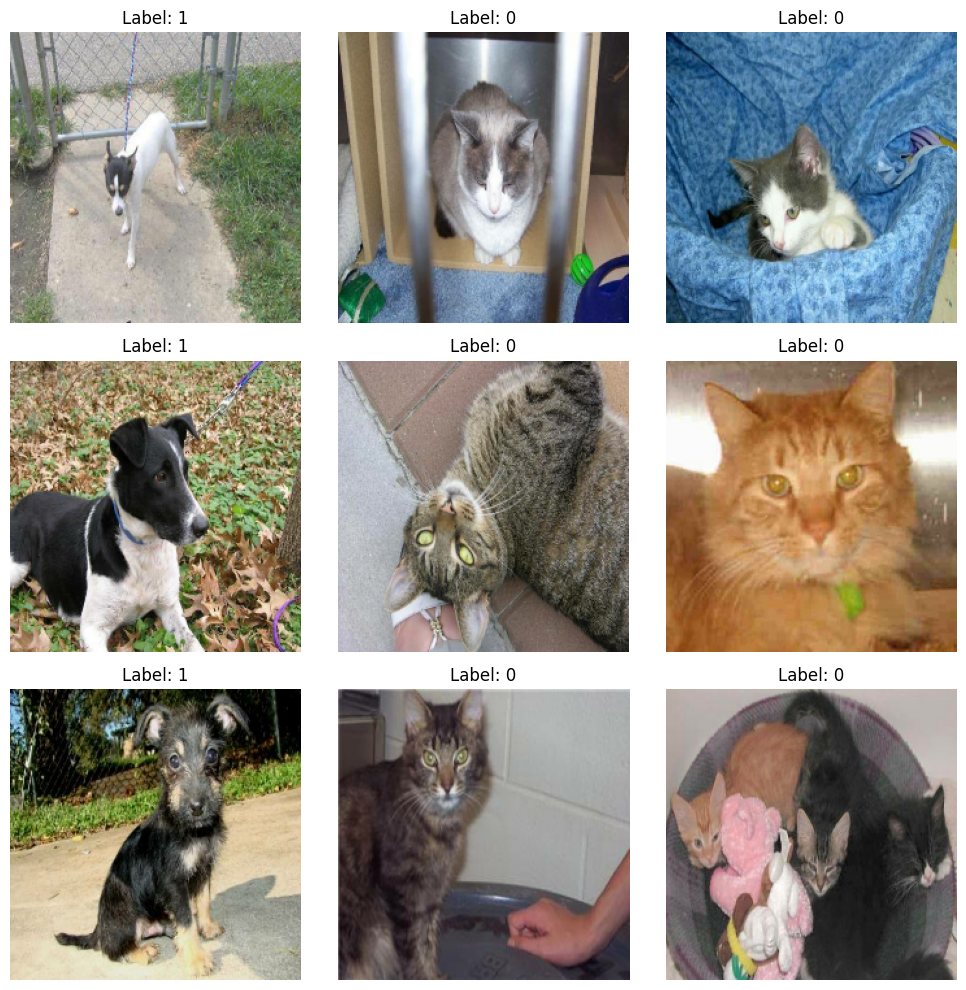

Sample images from the batch displayed successfully.


In [16]:
# Get a batch of images and labels from the dataset
for images, labels in train_data_set.take(1):
    break # We only need one batch

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8")) # Convert tensor to numpy array and scale to uint8 for display
    plt.title(f"Label: {int(labels[i])}") # Convert label to int for display
    plt.axis("off")
plt.tight_layout()
plt.show()

print("Sample images from the batch displayed successfully.")

In [17]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,BatchNormalization

In [18]:
from tensorflow.keras import regularizers

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

In [20]:
data_augmentation=keras.Sequential([
    layers.RandomFlip("flip",input_shape=(224,224,3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
normalization = tf.keras.layers.Rescaling(1./255)

In [22]:
model=keras.Sequential([
    data_augmentation,
    normalization,
    Conv2D(16,3,padding='same',activation='leaky_relu'),
    MaxPooling2D(),
    Conv2D(32,3,padding='same',activation='leaky_relu'),
    MaxPooling2D(),
    Conv2D(64,3,padding='same',activation='leaky_relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(256,activation='leaky_relu'),
    Dropout(0.2),
    Dense(128,activation='leaky_relu'),
    Dropout(0.2),
    Dense(64,activation='leaky_relu'),
    Dropout(0.2),
    Dense(1,activation='sigmoid')

])

In [23]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,910,113 (49.25 MB)

 Trainable params: 12,910,113 (49.25 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)

In [25]:
model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy'])

In [26]:
early=EarlyStopping(monitor='val_loss',patience=7,restore_best_weights=True,verbose=True)

In [27]:
history=model.fit(train_data_set,epochs=100,batch_size=32,validation_data=test_data_set,callbacks=[early])

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - accuracy: 0.5541 - loss: 0.7200 - val_accuracy: 0.5260 - val_loss: 0.7503
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.6284 - loss: 0.6438 - val_accuracy: 0.6745 - val_loss: 0.6013
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.6969 - loss: 0.5877 - val_accuracy: 0.7320 - val_loss: 0.5494
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.7291 - loss: 0.5387 - val_accuracy: 0.7450 - val_loss: 0.5165
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.7476 - loss: 0.5072 - val_accuracy: 0.7625 - val_loss: 0.4861
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.7720 - loss: 0.4800 - val_accuracy: 0.7650 - val_loss: 0.4930
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.7769 - loss: 0.4714 - val_accuracy: 0.7740 - val_loss: 0.4714
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.7943 - loss: 0

In [28]:
loss,accuracy=model.evaluate(test_data_set)
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.8270 - loss: 0.4070
Loss: 0.40703272819519043
Accuracy: 0.8270000219345093


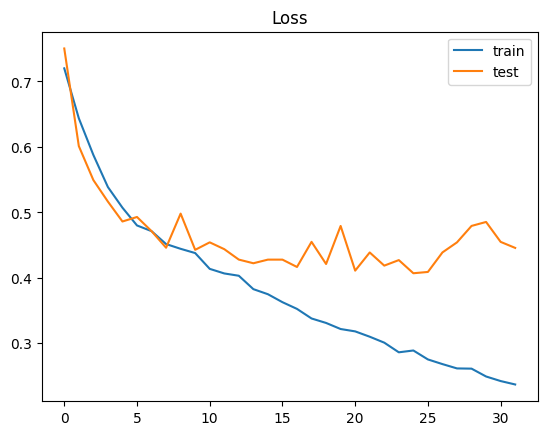

In [29]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','test'])
plt.title('Loss')
plt.show()

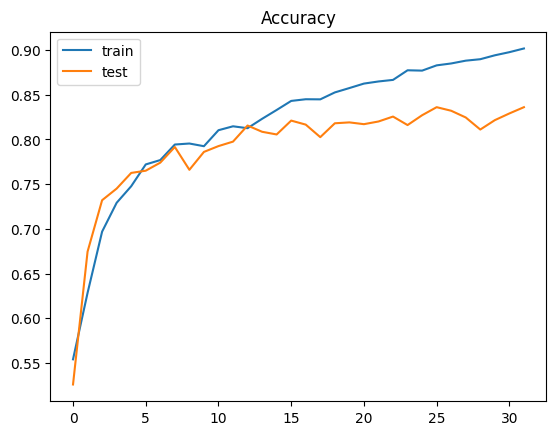

In [30]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','test'])
plt.title('Accuracy')
plt.show()

In [31]:
prediction=model.predict(prediction_data_set)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step


In [32]:
prediction

array([[0.9999654 ],
       [0.07731107]], dtype=float32)

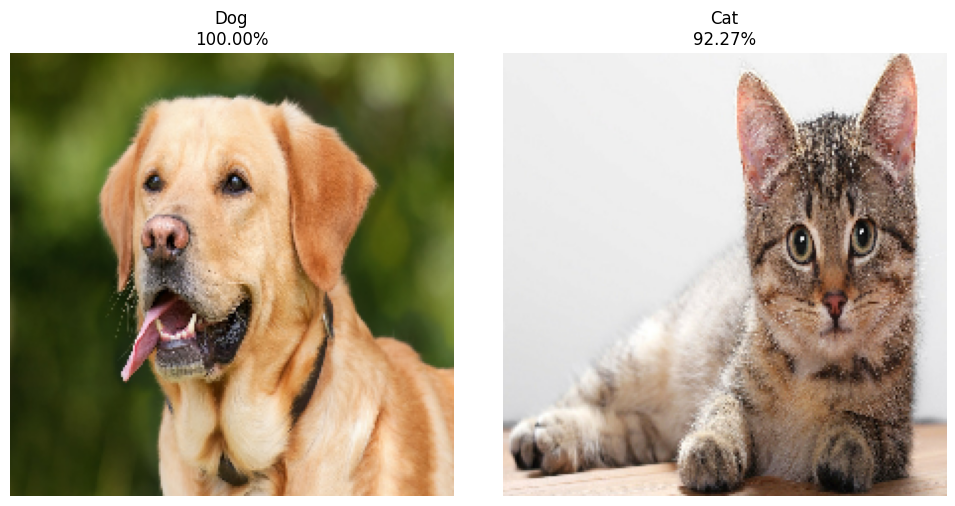

In [33]:
import matplotlib.pyplot as plt

# Get the images from the prediction dataset
for images in prediction_data_set.take(1):
    plt.figure(figsize=(10, 5))
    for i in range(len(images)):
        if i >= 10: break

        ax = plt.subplot(1, len(images), i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        # Get the prediction for this specific image
        prob = prediction[i][0]
        label = "Dog" if prob > 0.5 else "Cat"
        confidence = prob if prob > 0.5 else 1 - prob

        plt.title(f"{label}\n{confidence:.2%}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

.

.

# **Hyperparameter Tuning:**

In [34]:
pip install keras-tuner

In [35]:
import keras_tuner as kt

In [36]:
def build_model(hp):
  conv_units = hp.Int('conv_units', min_value=32, max_value=128, step=32)
  num_conv_layers = hp.Int('num_conv_layers', min_value=1, max_value=5, step=1)

  activation = hp.Choice('activation', values=['relu', 'leaky_relu', 'selu']) # Removed 'perametric_relu'

  # Optimizer choice
  optimizer_name = hp.Choice('optimizer', values=['Adam', 'AdamW', 'Nadam'])
  learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG', default=0.001)

  drop_out = hp.Float('drop_out', min_value=0.0, max_value=0.5, step=0.1)

  # Regularization choice
  regularizer_type = hp.Choice('regularizer', values=['None', 'l1', 'l2', 'l1_l2'])
  l1 = hp.Float('l1', min_value=1e-5, max_value=1e-1, sampling='LOG', default=0.01)
  l2 = hp.Float('l2', min_value=1e-5, max_value=1e-1, sampling='LOG', default=0.01)

  # Determine the regularizer
  current_regularizer = None
  if regularizer_type == 'l1':
    current_regularizer = regularizers.L1(l1)
  elif regularizer_type == 'l2':
    current_regularizer = regularizers.L2(l2)
  elif regularizer_type == 'l1_l2':
    current_regularizer = regularizers.L1L2(l1=l1, l2=l2)

  # Optimizer instantiation
  if optimizer_name == 'Adam':
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
  elif optimizer_name == 'AdamW':
    optimizer = tf.keras.optimizers.AdamW(learning_rate=learning_rate)
  else:
    optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)

  model = keras.Sequential()
  model.add(data_augmentation)
  model.add(normalization)

  # Convolutional Blocks
  for i in range(num_conv_layers):
    model.add(Conv2D(conv_units * (2**i), 3, padding='same', activation=activation, kernel_regularizer=current_regularizer))
    model.add(MaxPooling2D())
    model.add(Dropout(drop_out))

  model.add(Flatten())

  # Fully Connected Layers (FCL)
  num_dense_hidden_layers = hp.Int('num_dense_hidden_layers', min_value=1, max_value=3, step=1)

  for i in range(num_dense_hidden_layers):
    dense_units_i = hp.Int(f'dense_units_{i}', min_value=64, max_value=512, step=64)
    model.add(Dense(dense_units_i, activation=activation, kernel_regularizer=current_regularizer))
    model.add(Dropout(drop_out))

  model.add(Dense(1, activation='sigmoid')) # Output layer

  model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
  return model

In [37]:
tuner=kt.BayesianOptimization(
    build_model,
    objective='val_loss',
    max_trials=20,
    directory='cat_dog',
    project_name='dog_cat_classifier',
    overwrite=True

)

In [38]:
early_stop=EarlyStopping(monitor='val_loss',patience=6,restore_best_weights=True,verbose=True)

In [ ]:
tuner.search(train_data_set,epochs=10,batch_size=32,validation_data=test_data_set,callbacks=[early_stop])

Trial 3 Complete [00h 29m 34s]
val_loss: 0.6460754871368408

Best val_loss So Far: 0.6460754871368408
Total elapsed time: 01h 47m 08s

Search: Running Trial #4

Value             |Best Value So Far |Hyperparameter
96                |96                |conv_units
5                 |1                 |num_conv_layers
leaky_relu        |leaky_relu        |activation
AdamW             |AdamW             |optimizer
0.0053052         |0.0035583         |learning_rate
0.2               |0                 |drop_out
l1_l2             |l2                |regularizer
5.6106e-05        |6.6122e-05        |l1
4.4818e-05        |3.5651e-05        |l2
2                 |1                 |num_dense_hidden_layers
192               |64                |dense_units_0
128               |192               |dense_units_1
256               |256               |dense_units_2

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 182s 696ms/step - accuracy: 0.5050 - loss: 14961.9209 - val_accuracy: 0.5005 - val_loss: 189.371

In [ ]:
best_hp=tuner.get_best_hyperparameter(num_trials=1)[0]

In [ ]:
print(f"Best Units per Layer: {best_hp.get('conv_units')}")
print(f"Best Number of Layers: {best_hp.get('num_conv_layers')}")
print(f"Best Activation Function: {best_hp.get('activation')}")
print(f"Best Optimizer: {best_hp.get('optimizer')}")
print(f"Best Learning Rate: {best_hp.get('learning_rate')}")
print(f"Best Dropout Rate: {best_hp.get('drop_out')}")
print(f"Best Regularizer: {best_hp.get('regularizer')}")
print(f"Best L1 Regularization Strength: {best_hp.get('l1')}")
print(f"Best L2 Regularization Strength: {best_hp.get('l2')}")
print(f"Best Number of Dense Hidden Layers: {best_hp.get('num_dense_hidden_layers')}")
print(f"Best Units per Dense Layer: {best_hp.get('dense_units_0')}")
print(f"Best Units per Dense Layer: {best_hp.get('dense_units_1')}")
print(f"Best Units per Dense Layer: {best_hp.get('dense_units_2')}")
print(f"Best Units per Dense Layer: {best_hp.get('dense_units_3')}")
print(f"Best Units per Dense Layer: {best_hp.get('dense_units_4')}")
print(f"Best Units per Dense Layer: {best_hp.get('dense_units_5')}")

In [ ]:
best_model = tuner.hypermodel.build(best_hp)

In [ ]:
history_all = best_model.fit(train_data_set,epochs=50,batch_size=32,validation_data=test_data_set,callbacks=[early])

In [ ]:
test_loss, test_acc = best_model.evaluate(test_data_set)
print(f"Test loss with best hyperparameters: {test_loss:.4f}")
print(f"Test Accuracy with best hyperparameters: {test_acc:.4f}")

In [ ]:
plt.plot(history_all.history['loss'])
plt.plot(history_all.history['val_loss'])
plt.legend(['train','test'])
plt.title('Loss')
plt.show()

In [ ]:
plt.plot(history_all.history['accuracy'])
plt.plot(history_all.history['val_accuracy'])
plt.legend(['train','test'])
plt.title('Accuracy')
plt.show()